In [1]:
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

from util import TripletModel, validate_model, train_model, animate, get_base_rod

jax.config.update("jax_enable_x64", True)


class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array# = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(der_K.shape[0], 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        return 0.5 * jnp.sum(self.K * del_strain**2) + self.mlp(del_strain)


validate_model(Example)
final_model = train_model(Example)

Step 0    | Train: 2.07811e-04  | Valid: 1.86523e-04 
Step 10   | Train: 2.90739e-04  | Valid: 9.66823e-05 
Step 20   | Train: 1.52402e-04  | Valid: 1.54623e-04 
Step 30   | Train: 2.78169e-05  | Valid: 2.60491e-05 
Step 40   | Train: 4.98206e-06  | Valid: 4.44185e-06 
Step 50   | Train: 3.08096e-06  | Valid: 3.59882e-06 
Step 60   | Train: 3.07770e-06  | Valid: 3.61409e-06 
Step 70   | Train: 2.19448e-06  | Valid: 3.14681e-06 
Step 80   | Train: 2.01574e-06  | Valid: 3.11013e-06 
Step 90   | Train: 2.01467e-06  | Valid: 2.92558e-06 
Step 100  | Train: 1.87716e-06  | Valid: 2.61234e-06 
Step 110  | Train: 1.77563e-06  | Valid: 2.49277e-06 
Step 120  | Train: 1.75031e-06  | Valid: 2.51796e-06 
Step 130  | Train: 1.69993e-06  | Valid: 2.48782e-06 
Step 140  | Train: 1.65329e-06  | Valid: 2.43160e-06 
Step 150  | Train: 1.63027e-06  | Valid: 2.42793e-06 
Step 160  | Train: 1.60476e-06  | Valid: 2.43550e-06 
Step 170  | Train: 1.58416e-06  | Valid: 2.43467e-06 
Step 180  | Train: 1.57114e-

In [2]:
from util import TestCase

valid = TestCase.from_npz("valid.npz")
lambdas = jnp.linspace(0.0, 1.0, valid.qs.shape[1])

base, aux, _ = get_base_rod()
rods = base.with_bc(valid.bc)
pred = rods.batch_solve(final_model, lambdas, aux, max_dt=5e-3, iters=5, ls_steps=10)[0]
animate(pred)

In [3]:
animate(valid.qs)

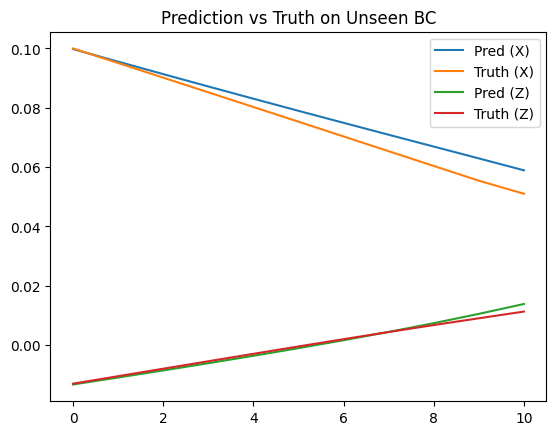

In [4]:
import matplotlib.pyplot as plt

plt.plot(pred[:, 4], label="Pred (X)")
plt.plot(valid.qs[:, 4], label="Truth (X)")
# plt.plot(pred[:, 5], label="Pred (Y)")
# plt.plot(valid.qs[:, 5], label="Truth (Y)")
plt.plot(pred[:, 6], label="Pred (Z)")
plt.plot(valid.qs[:, 6], label="Truth (Z)")
plt.legend()
plt.title("Prediction vs Truth on Unseen BC")
plt.show()